# Financial Inclusion — LazyPredict Model Comparison

---

**Ziel:** Schneller Überblick über 20+ Klassifizierer in einem Durchlauf.

LazyPredict trainiert automatisch alle gängigen sklearn-Modelle und gibt eine Vergleichstabelle zurück — so sehen wir welche Modell-Familien auf unseren Daten gut funktionieren, bevor wir Zeit in Tuning investieren.

> **Hinweis:** LazyPredict nutzt keinen optimierten Threshold und kein `scale_pos_weight` — die Ergebnisse sind daher Richtwerte, nicht finale Scores.

---
### Step 0 — Imports

In [2]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from lazypredict.Supervised import LazyClassifier

import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
print('Imports erfolgreich.')

Imports erfolgreich.


---
### Step 1 — Daten laden & aufteilen

In [3]:
df = pd.read_csv('data/features_encoded_train.csv')

X = df.drop(columns=['target_bank_account'])
y = df['target_bank_account']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f'Train: {len(X_train):,} | Test: {len(X_test):,}')
print(f'Konto (1): {y_train.mean()*100:.1f}%  |  Kein Konto (0): {(1-y_train.mean())*100:.1f}%')

Train: 18,819 | Test: 4,705
Konto (1): 14.1%  |  Kein Konto (0): 85.9%


---
### Step 2 — LazyPredict ausführen

LazyPredict trainiert alle verfügbaren sklearn-Klassifizierer automatisch und gibt eine sortierte Tabelle zurück mit:
- **ROC AUC** — unsere Hauptmetrik
- **F1 Score** — Balance zwischen Precision und Recall
- **Accuracy** — Gesamtgenauigkeit
- **Time Taken** — Trainingszeit in Sekunden

In [4]:
clf = LazyClassifier(
    verbose=0,
    ignore_warnings=True,
    custom_metric=None,
    predictions=False,
)

models, predictions = clf.fit(X_train, X_test, y_train, y_test)

# Nach ROC AUC sortieren
models = models.sort_values('ROC AUC', ascending=False)

print(f'Anzahl getesteter Modelle: {len(models)}')
print()
models

Anzahl getesteter Modelle: 26



,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Precision,Recall,Time Taken
Model,,,,,,,
LGBMClassifier,0.890117,0.675836,0.872072,0.875541,0.876998,0.890117,0.734244
XGBClassifier,0.887991,0.677126,0.866895,0.874286,0.874180,0.887991,0.216021
AdaBoostClassifier,0.885654,0.661870,0.860829,0.869470,0.870656,0.885654,0.182799
CalibratedClassifierCV,0.887354,0.659070,0.856874,0.870024,0.873229,0.887354,2.107758
LinearSVC,0.886716,0.646066,0.856783,0.866536,0.873106,0.886716,0.569198
LogisticRegression,0.885654,0.655554,0.856749,0.868062,0.870686,0.885654,0.021343
RidgeClassifierCV,0.884378,0.628916,0.852766,0.860548,0.871019,0.884378,0.020860
RidgeClassifier,0.884166,0.628792,0.852763,0.860378,0.870572,0.884166,0.035067
LinearDiscriminantAnalysis,0.885016,0.673500,0.852761,0.871458,0.870315,0.885016,0.048266


---
### Step 3 — Visualisierung

Top 15 Modelle nach ROC AUC als Balkendiagramm.

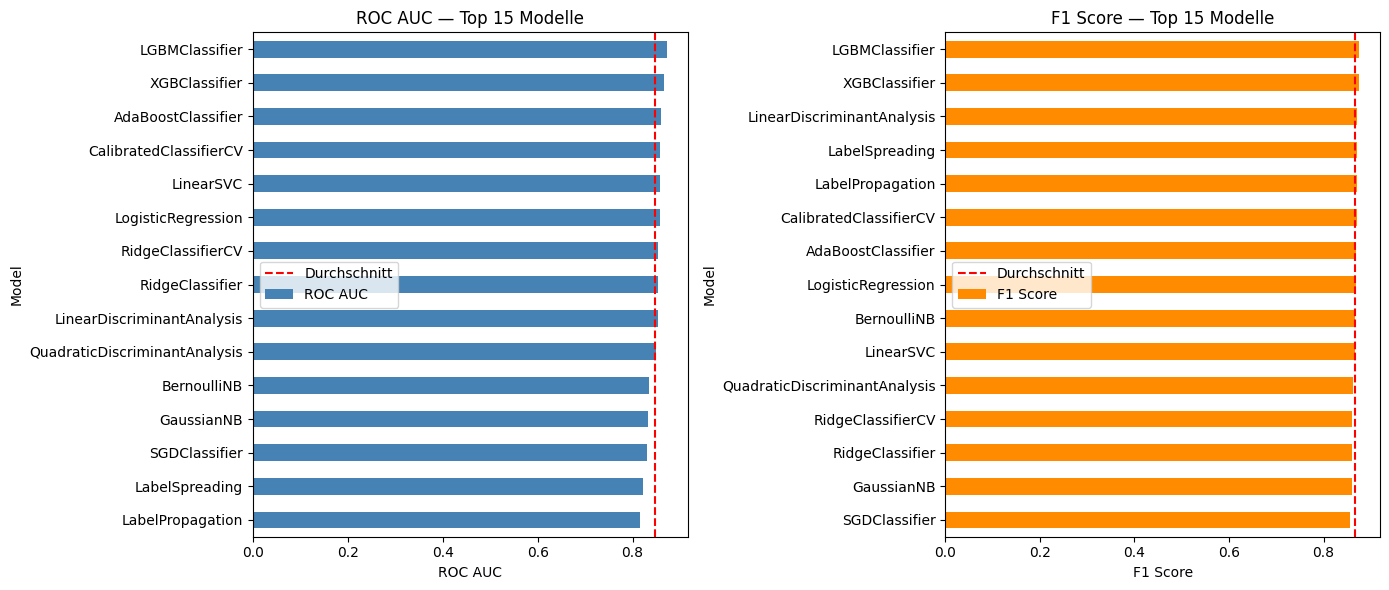

In [5]:
top15 = models.head(15)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ROC AUC
top15['ROC AUC'].sort_values().plot(
    kind='barh', ax=axes[0], color='steelblue'
)
axes[0].set_title('ROC AUC — Top 15 Modelle')
axes[0].set_xlabel('ROC AUC')
axes[0].axvline(top15['ROC AUC'].mean(), color='red', linestyle='--', label='Durchschnitt')
axes[0].legend()

# F1 Score
top15['F1 Score'].sort_values().plot(
    kind='barh', ax=axes[1], color='darkorange'
)
axes[1].set_title('F1 Score — Top 15 Modelle')
axes[1].set_xlabel('F1 Score')
axes[1].axvline(top15['F1 Score'].mean(), color='red', linestyle='--', label='Durchschnitt')
axes[1].legend()

plt.tight_layout()
plt.show()

---
### Step 4 — Fazit & nächste Schritte

Die Top-Modelle aus dieser Tabelle sind die Kandidaten für dedizierte Notebooks mit:
- `scale_pos_weight` / `class_weight` für Financial Inclusion
- Hyperparameter Tuning via GridSearch / RandomizedSearch
- Threshold-Optimierung auf Recall (F2-Score)

In [6]:
print('=== Top 5 Modelle nach ROC AUC ===')
print(models[['ROC AUC', 'F1 Score', 'Accuracy', 'Time Taken']].head(5).to_string())
print()
print('=== Schnellste Modelle (Zeit < 1s) mit AUC > 0.80 ===')
fast = models[(models['Time Taken'] < 1) & (models['ROC AUC'] > 0.80)]
if len(fast):
    print(fast[['ROC AUC', 'F1 Score', 'Time Taken']].to_string())
else:
    print('Keine Modelle gefunden — Schwelle anpassen.')

=== Top 5 Modelle nach ROC AUC ===
                         ROC AUC  F1 Score  Accuracy  Time Taken
Model                                                           
LGBMClassifier          0.872072  0.875541  0.890117    0.734244
XGBClassifier           0.866895  0.874286  0.887991    0.216021
AdaBoostClassifier      0.860829  0.869470  0.885654    0.182799
CalibratedClassifierCV  0.856874  0.870024  0.887354    2.107758
LinearSVC               0.856783  0.866536  0.886716    0.569198

=== Schnellste Modelle (Zeit < 1s) mit AUC > 0.80 ===
                                ROC AUC  F1 Score  Time Taken
Model                                                        
LGBMClassifier                 0.872072  0.875541    0.734244
XGBClassifier                  0.866895  0.874286    0.216021
AdaBoostClassifier             0.860829  0.869470    0.182799
LinearSVC                      0.856783  0.866536    0.569198
LogisticRegression             0.856749  0.868062    0.021343
RidgeClassifierCV    

Dein getuntes XGBoost (0.8719) schlägt den ungetunten XGBoost aus LazyPredict (0.8669) — das Tuning hat sich gelohnt
LightGBM (LGBM) steht ganz oben — das wäre der nächste logische Kandidat für ein dediziertes Notebook
RandomForest fällt deutlich ab (0.8148) — weniger vielversprechend
